## 1. Setup & Config {#1}

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns
import shap
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# ────────────────────────────────────────────────
# CONFIG 
# ────────────────────────────────────────────────
OUTPUT_DIR = Path("D:\CODEPY\Fashion_Ecom_Sales_Forecasting\outputs")  # Local

MODEL_DIR = OUTPUT_DIR / "models_deep_tune"
DATA_FILE = OUTPUT_DIR / "daily_features_tuned_best.csv"

DATE_COL = "date"
TARGET_REVENUE = "revenue"
TARGET_COGS = "cogs"

print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"MODEL_DIR: {MODEL_DIR}")
print(f"DATA_FILE exists: {DATA_FILE.exists()}")
print(f"OUTPUT_DIR exists: {OUTPUT_DIR.exists()}")



OUTPUT_DIR: D:\CODEPY\Fashion_Ecom_Sales_Forecasting\outputs
MODEL_DIR: D:\CODEPY\Fashion_Ecom_Sales_Forecasting\outputs\models_deep_tune
DATA_FILE exists: True
OUTPUT_DIR exists: True


## 2. Đánh giá Model - Metrics Đầy đủ {#2}

In [2]:
# ────────────────────────────────────────────────
# Helper metrics
# ────────────────────────────────────────────────
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (%)."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def wmape(y_true, y_pred):
    """Weighted MAPE - scale-independent, industry-standard for revenue forecasting."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    total = np.sum(np.abs(y_true))
    if total == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / total * 100)


def load_compare(target_name):
    """Load model comparison CSV cho một target."""
    path = OUTPUT_DIR / f"{target_name}_family_compare_plus_ensemble.csv"
    if not path.exists():
        print(f"[WARN] Khong tim thay: {path}")
        return None
    df = pd.read_csv(path)
    cols = ["model_family", "mean_rmse", "std_rmse",
            "mean_mae", "std_mae",
            "mean_r2", "std_r2",
            "mean_mape", "std_mape",
            "mean_wmape", "std_wmape",
            "folds", "runtime_used"]
    existing = [c for c in cols if c in df.columns]
    return df[existing].sort_values(["mean_rmse", "mean_mae"])


def style_metrics(df, target_label):
    """Format bảng metrics đẹp."""
    if df is None:
        return
    display(HTML(f"<h3>{target_label}</h3>"))
    
    rename = {
        "model_family": "Model",
        "mean_rmse": "RMSE", "std_rmse": "RMSE_std",
        "mean_mae": "MAE", "std_mae": "MAE_std",
        "mean_r2": "R²", "std_r2": "R²_std",
        "mean_mape": "MAPE%", "std_mape": "MAPE%_std",
        "mean_wmape": "WMAPE%", "std_wmape": "WMAPE%_std",
        "folds": "Folds", "runtime_used": "Runtime",
    }
    

    df = df.rename(columns=rename)
    
 
    format_dict = {
        "RMSE": "{:,.0f}", "RMSE_std": "{:,.0f}",
        "MAE": "{:,.0f}", "MAE_std": "{:,.0f}",
        "R²": "{:.4f}", "R²_std": "{:.4f}",
        "MAPE%": "{:.2f}%", "MAPE%_std": "{:.2f}%",
        "WMAPE%": "{:.2f}%", "WMAPE%_std": "{:.2f}%",
    }
    
    
    valid_format_dict = {k: v for k, v in format_dict.items() if k in df.columns}
    
    
    color_subset = ["RMSE", "MAE", "MAPE%", "WMAPE%"]
    valid_color_subset = [c for c in color_subset if c in df.columns]
    
    return df.style.format(valid_format_dict, na_rep="N/A").background_gradient(
        subset=valid_color_subset, cmap="RdYlGn_r"
    ).set_caption(f"Model Comparison - {target_label}")


from IPython.display import display, HTML, Image as IPImage

print("=" * 70)
print("DOANH THU (REVENUE) - Model Comparison")
print("=" * 70)
df_rev = load_compare(TARGET_REVENUE)
if df_rev is not None:

    styled = style_metrics(df_rev.copy(), "DOANH THU (REVENUE)")
    display(styled)
else:
    print("  -> File khong ton tai. Hay chay Datathon.ipynb truoc.")

print()
print("=" * 70)
print("GIA VON (COGS) - Model Comparison")
print("=" * 70)
df_cogs = load_compare(TARGET_COGS)
if df_cogs is not None:
    styled = style_metrics(df_cogs.copy(), "GIA VON (COGS)")
    display(styled)
else:
    print("  -> File khong ton tai. Hay chay Datathon.ipynb truoc.")


if df_rev is not None and df_cogs is not None:
    manifest_path = OUTPUT_DIR / "deep_tune_run_manifest.json"
    if manifest_path.exists():
        with open(manifest_path) as f:
            manifest = json.load(f)
        print()
        print("=" * 70)
        print("CHON LOC MO HINH")
        print("=" * 70)
        print(f"  Revenue: {manifest['best_final_choice']['revenue']}")
        print(f"  COGS:    {manifest['best_final_choice']['cogs']}")
        print(f"  Runtime: {manifest['runtime_choices']}")
        print(f"  Features: Revenue={manifest['revenue_features']}, COGS={manifest['cogs_features']}")

DOANH THU (REVENUE) - Model Comparison


,Model,RMSE,RMSE_std,MAE,MAE_std,R²,R²_std,Folds,Runtime
0,ensemble_mean,"562,155","44,827","444,553","11,170",0.3727,0.1082,2,mixed
1,xgb,"576,076","28,916","454,523","14,885",0.3308,0.1536,2,gpu
2,cat,"590,723","65,071","466,651","38,551",0.3174,0.0767,2,gpu
3,lgbm,"590,907","58,486","472,698","23,446",0.3134,0.0925,2,gpu



GIA VON (COGS) - Model Comparison


,Model,RMSE,RMSE_std,MAE,MAE_std,R²,R²_std,Folds,Runtime
0,xgb,"542,387","46,562","421,197","18,103",0.3974,0.0202,2,gpu
1,ensemble_mean,"550,555","35,870","433,595","7,355",0.3757,0.0469,2,mixed
2,lgbm,"563,264","5,262","452,025","20,644",0.3342,0.1231,2,gpu
3,cat,"567,244","54,211","438,093","23,008",0.3423,0.0092,2,gpu



CHON LOC MO HINH
  Revenue: ensemble_mean
  COGS:    xgb
  Runtime: {'lgbm': 'gpu', 'xgb': 'gpu', 'cat': 'gpu'}
  Features: Revenue=82, COGS=82


## 3. Feature Importance {#3}

Revenue model: best_revenue_cat.joblib (82 features)
Top 20 features:
                  feature  importance
            revenue_lag_1   35.594716
          revenue_lag_365   12.224428
          revenue_lag_364    9.253294
                      day    8.506821
            revenue_lag_7    6.770152
           revenue_lag_14    3.862706
                 time_idx    2.426961
           revenue_lag_56    2.358578
           revenue_lag_28    2.134171
          revenue_lag_366    1.534217
days_since_prev_mega_sale    1.245368
                  doy_sin    0.978548
       revenue_roll_std_7    0.923175
                  dow_cos    0.851409
                  dow_sin    0.826899
      promo_discount_mean    0.822029
              day_of_week    0.743372
           revenue_lag_84    0.691930
      revenue_ewm_mean_28    0.643228
      revenue_roll_std_14    0.615806

COGS model: best_cogs_xgb.joblib (82 features)
Top 20 features:
               feature  importance
            cogs_lag_1    0.3238

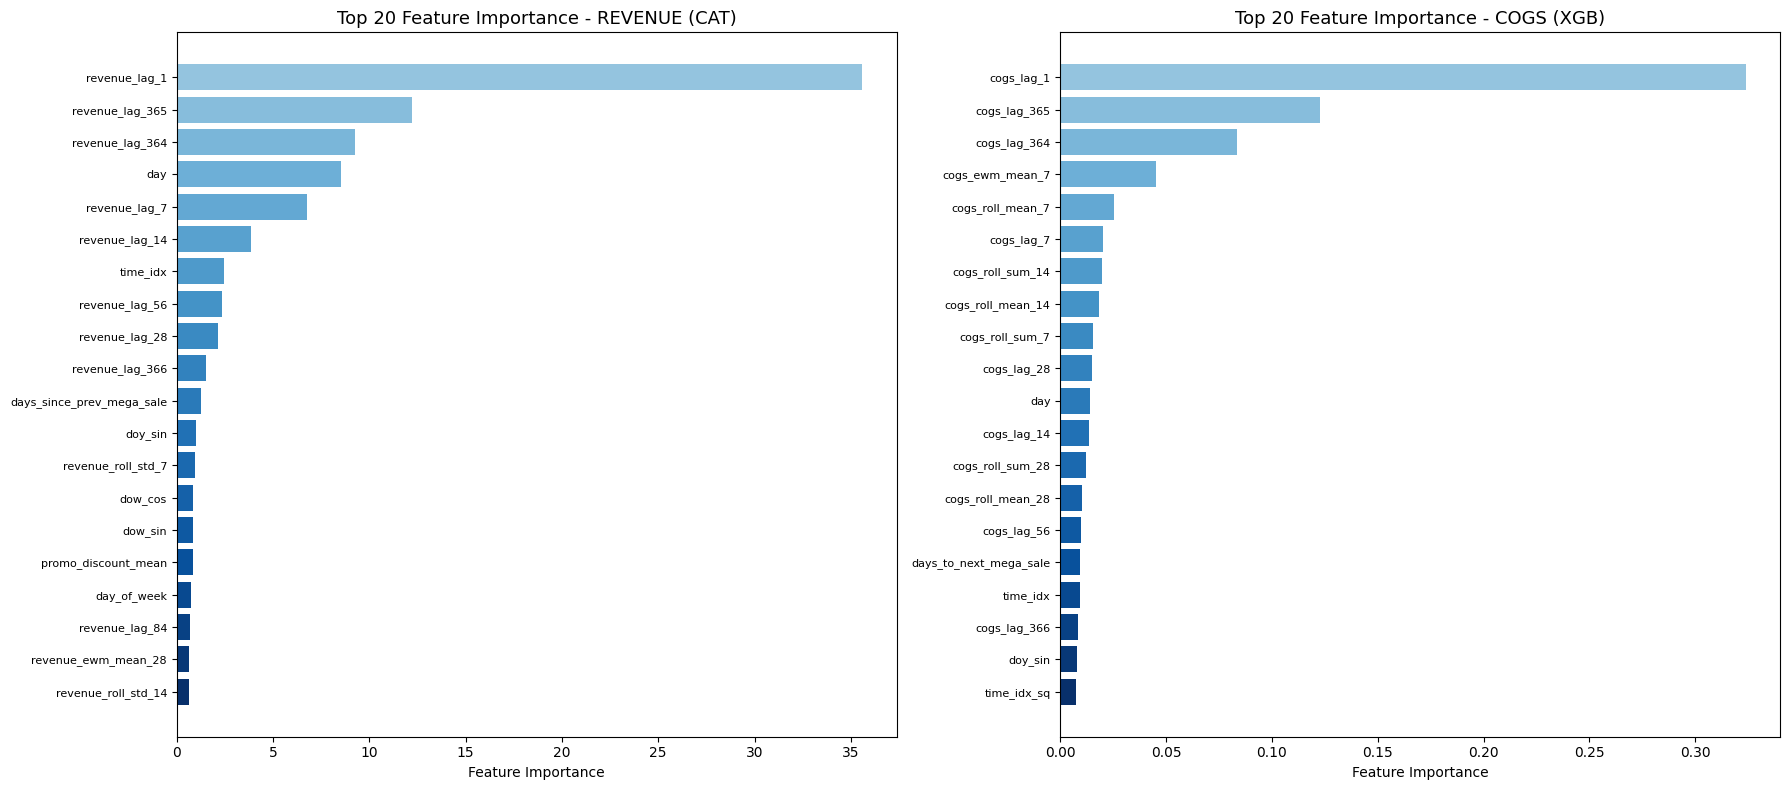

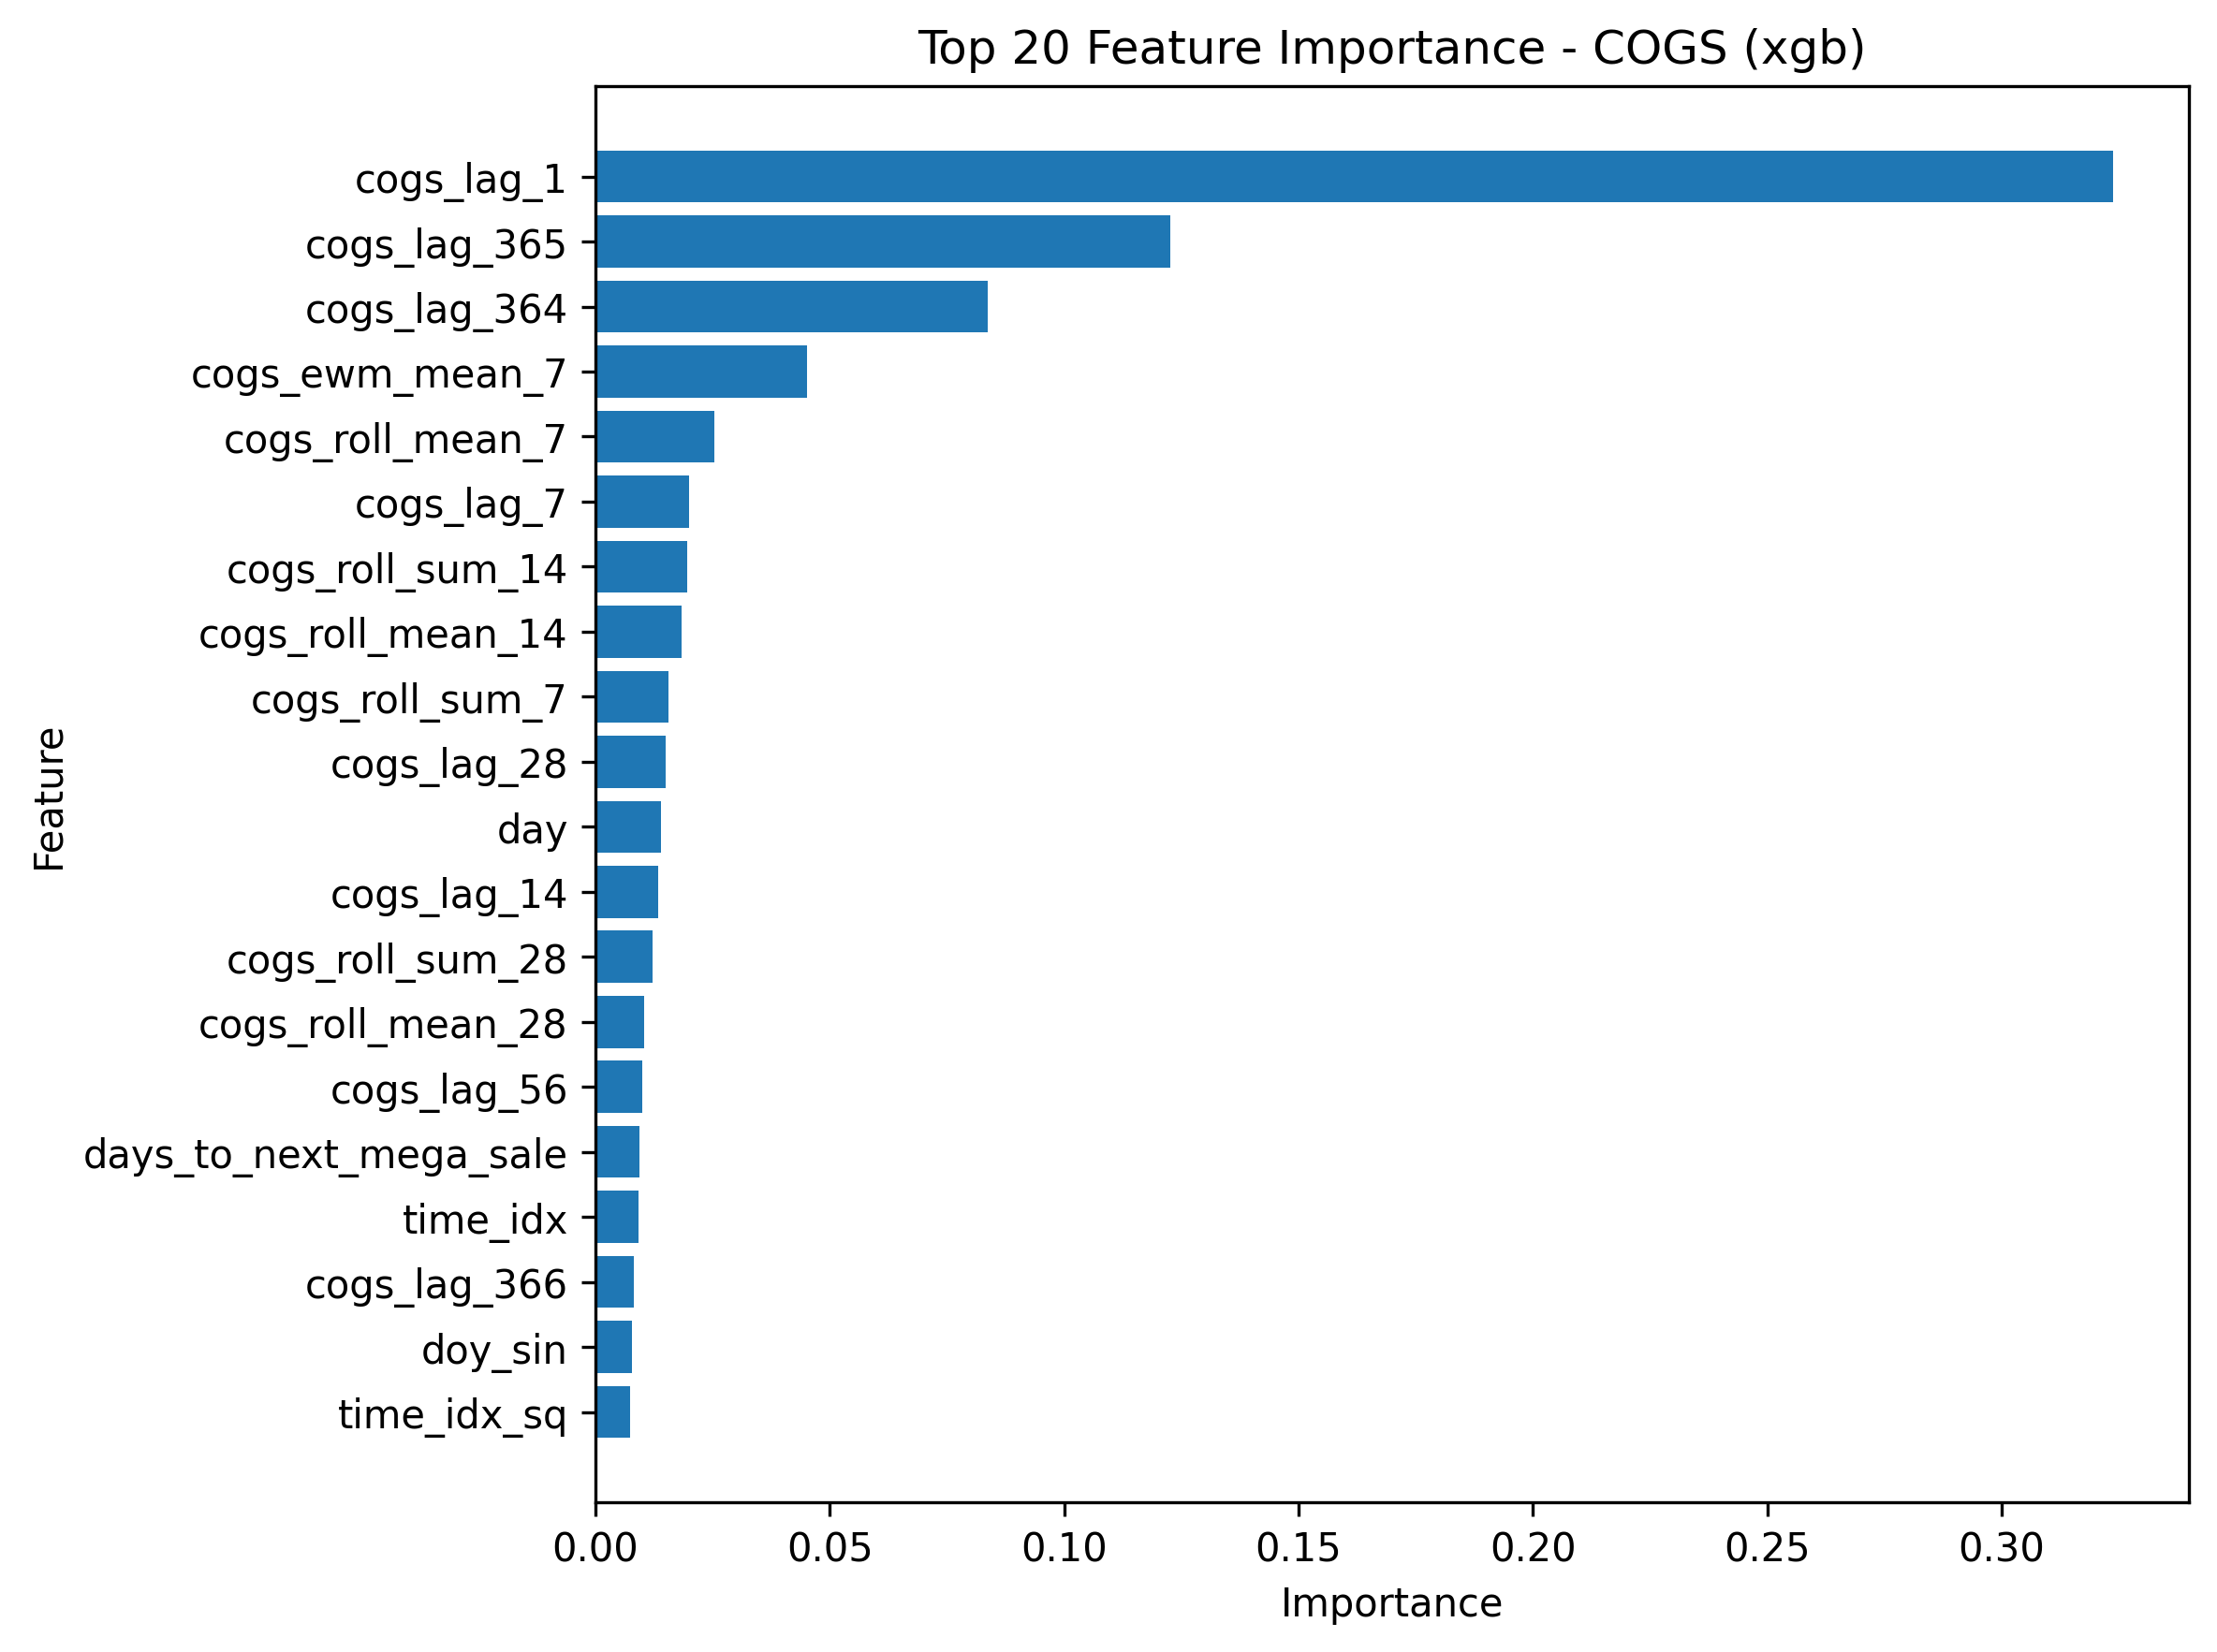

In [3]:
# ────────────────────────────────────────────────
# Feature Importance cho Revenue
# ────────────────────────────────────────────────
manifest_path = OUTPUT_DIR / "deep_tune_run_manifest.json"
if not manifest_path.exists():
    print("[WARN] Khong tim thay manifest. Hay chay Datathon.ipynb truoc.")
else:
    with open(manifest_path) as f:
        manifest = json.load(f)

    best_rev_family = manifest["best_final_choice"][TARGET_REVENUE]
    best_cogs_family = manifest["best_final_choice"][TARGET_COGS]

    rev_model_path = MODEL_DIR / f"best_{TARGET_REVENUE}_{best_rev_family}.joblib"
    cogs_model_path = MODEL_DIR / f"best_{TARGET_COGS}_{best_cogs_family}.joblib"
    
    if not rev_model_path.exists():
        for fam in ["cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_REVENUE}_{fam}.joblib"
            if p.exists():
                rev_model_path = p
                best_rev_family = fam
                break
    if not cogs_model_path.exists():
        for fam in ["cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_COGS}_{fam}.joblib"
            if p.exists():
                cogs_model_path = p
                best_cogs_family = fam
                break

    if rev_model_path.exists():
        rev_model = joblib.load(rev_model_path)
        rev_feature_cols = getattr(rev_model, "feature_names_in_", getattr(rev_model, "feature_names_", getattr(rev_model, "feature_name_", None)))
        rev_importance = pd.DataFrame({
            "feature": rev_feature_cols,
            "importance": rev_model.feature_importances_,
        }).sort_values("importance", ascending=False).reset_index(drop=True)

        print(f"Revenue model: {rev_model_path.name} ({len(rev_feature_cols)} features)")
        print(f"Top 20 features:")
        print(rev_importance.head(20).to_string(index=False))
    else:
        print("[WARN] Khong tim thay model revenue. Ve bieu do tu file PNG co san.")
        rev_importance = None

    if cogs_model_path.exists():
        cogs_model = joblib.load(cogs_model_path)
        cogs_feature_cols = getattr(cogs_model, "feature_names_in_", getattr(cogs_model, "feature_names_", getattr(cogs_model, "feature_name_", None)))
        cogs_importance = pd.DataFrame({
            "feature": cogs_feature_cols,
            "importance": cogs_model.feature_importances_,
        }).sort_values("importance", ascending=False).reset_index(drop=True)

        print(f"\nCOGS model: {cogs_model_path.name} ({len(cogs_feature_cols)} features)")
        print(f"Top 20 features:")
        print(cogs_importance.head(20).to_string(index=False))
    else:
        print("[WARN] Khong tim thay model COGS.")
        cogs_importance = None

    # Ve Feature Importance chart
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, imp_df, name, fam in zip(
        axes,
        [rev_importance, cogs_importance],
        ["Revenue", "COGS"],
        [best_rev_family, best_cogs_family]
    ):
        if imp_df is None:
            ax.set_visible(False)
            continue
        top = imp_df.head(20).sort_values("importance", ascending=True)
        colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(top)))[::-1]
        ax.barh(top["feature"], top["importance"], color=colors)
        ax.set_xlabel("Feature Importance")
        ax.set_title(f"Top 20 Feature Importance - {name.upper()} ({fam.upper()})", fontsize=13)
        ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_combined.png", dpi=300, bbox_inches="tight")
    plt.show()

    for name, fam in [("revenue", best_rev_family), ("cogs", best_cogs_family)]:
        png_path = OUTPUT_DIR / f"feature_importance_{name}_{fam}.png"
        if png_path.exists():
            display(IPImage(filename=str(png_path)))

## 4. Forecast vs Actual - Backtest Visualization {#4}

Biểu đồ này cho thấy giá trị **thực tế (actual)** so với **dự báo (forecast)** 
trên tập backtest validation, giúp đánh giá chất lượng model một cách trực quan.

So folds backtest: 2
Horizon: 60 ngay, Min train: 730


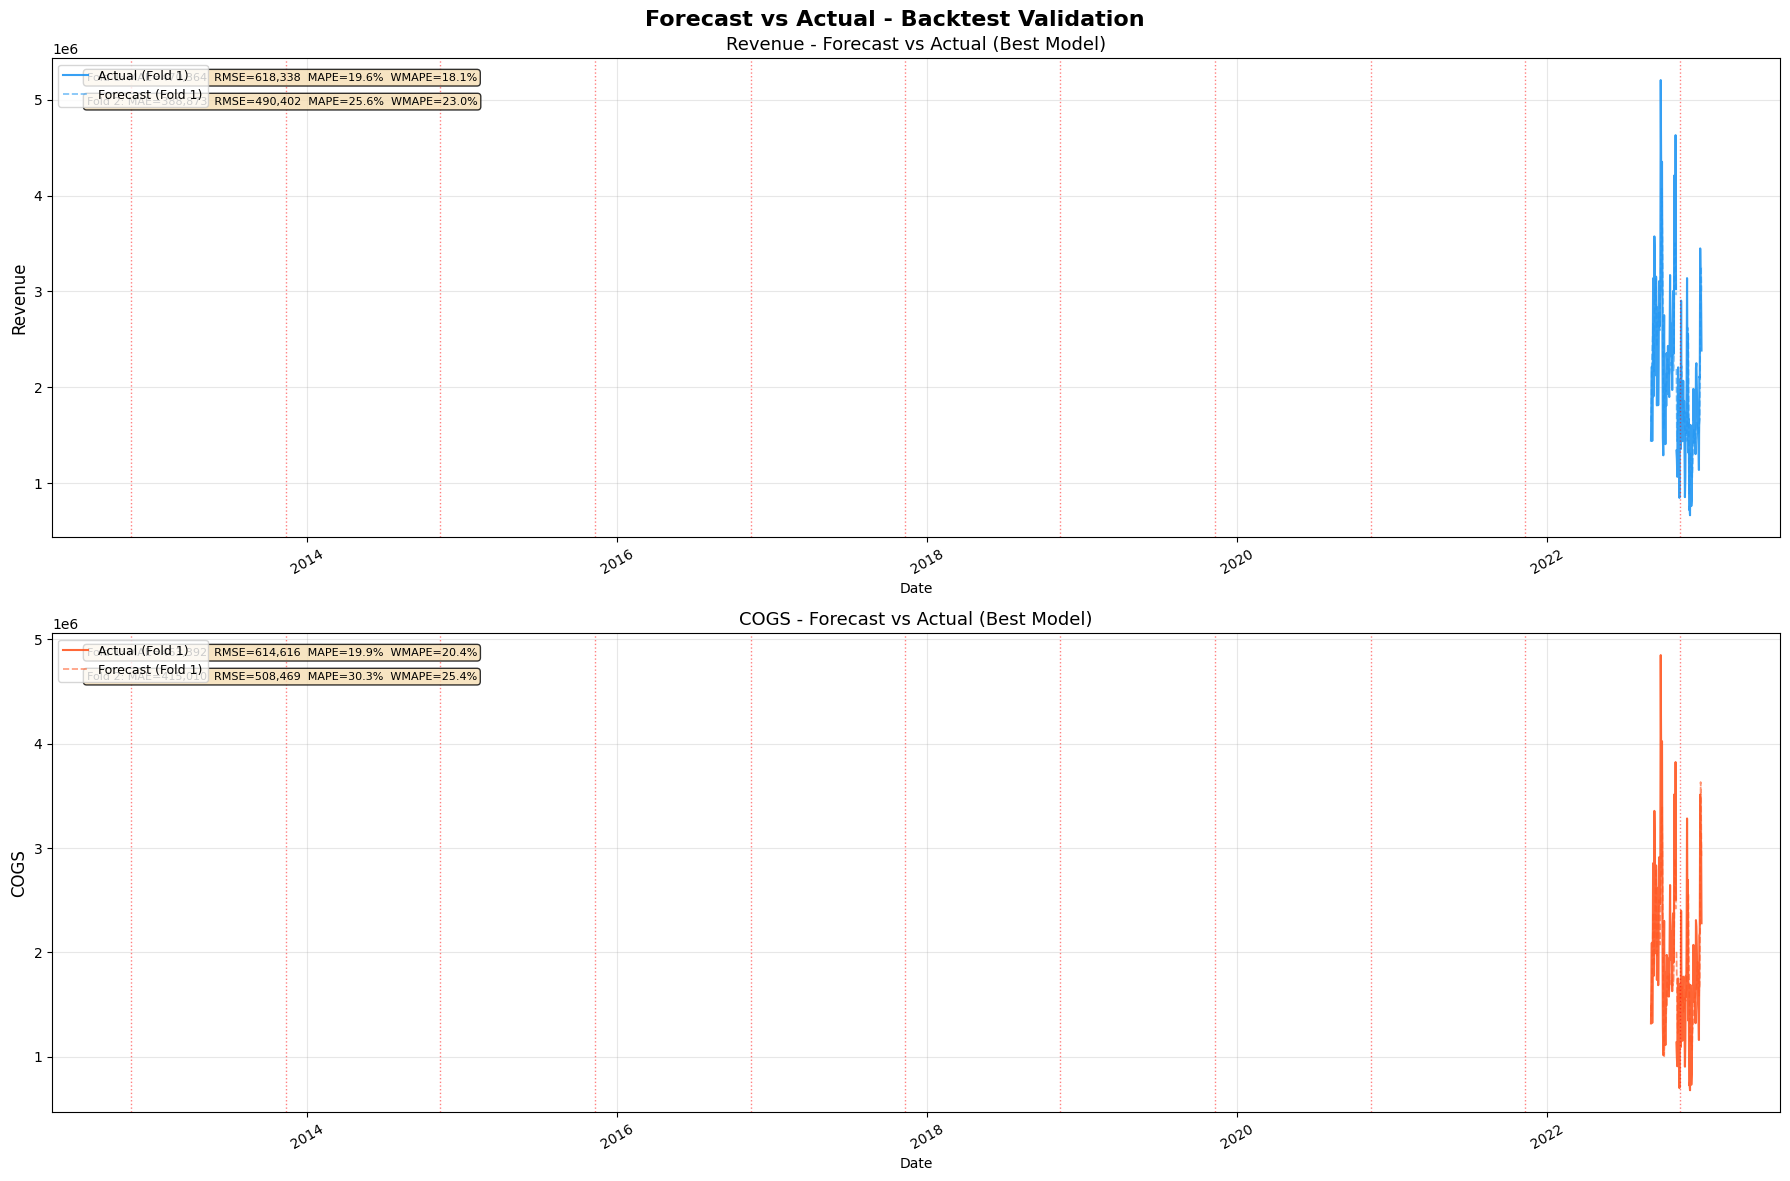

In [4]:
# ────────────────────────────────────────────────
# Forecast vs Actual cho backtest folds
# ────────────────────────────────────────────────
if not DATA_FILE.exists():
    print("[WARN] Khong tim thay DATA_FILE. Hay chay Datathon.ipynb truoc.")
else:
    df = pd.read_csv(DATA_FILE, parse_dates=[DATE_COL])
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    train_df = df[df[TARGET_REVENUE].notna()].copy()
    
    manifest_path = OUTPUT_DIR / "deep_tune_run_manifest.json"
    if not manifest_path.exists():
        print("[WARN] Khong tim thay manifest.")
    else:
        with open(manifest_path) as f:
            manifest = json.load(f)

        best_rev_family = manifest["best_final_choice"][TARGET_REVENUE]
        best_cogs_family = manifest["best_final_choice"][TARGET_COGS]
        
        # Load best models
        rev_model_path = None
        cogs_model_path = None
        for fam in [best_rev_family, "cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_REVENUE}_{fam}.joblib"
            if p.exists():
                rev_model_path = p
                break
        for fam in [best_cogs_family, "cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_COGS}_{fam}.joblib"
            if p.exists():
                cogs_model_path = p
                break
        
        if rev_model_path is None or cogs_model_path is None:
            print("[WARN] Khong tim thay model files. Khong ve duoc forecast chart.")
        else:
            rev_model = joblib.load(rev_model_path)
            cogs_model = joblib.load(cogs_model_path)

            rev_feature_cols = list(getattr(rev_model, "feature_names_in_", getattr(rev_model, "feature_names_", getattr(rev_model, "feature_name_", []))))
            cogs_feature_cols = list(getattr(cogs_model, "feature_names_in_", getattr(cogs_model, "feature_names_", getattr(cogs_model, "feature_name_", []))))

 
            n_folds = manifest.get("folds", 2)
            horizon = manifest.get("horizon", 60)
            min_train = manifest.get("min_train_rows", 730)
            
            n = len(train_df)
            splits = []
            for i in range(n_folds, 0, -1):
                vs = n - i * horizon
                ve = vs + horizon
                if vs >= min_train and ve <= n:
                    splits.append((np.arange(0, vs), np.arange(vs, ve)))

            print(f"So folds backtest: {len(splits)}")
            print(f"Horizon: {horizon} ngay, Min train: {min_train}")

            def make_calendar_row(dt):
                dt = pd.Timestamp(dt)
                mmdd = dt.strftime("%m-%d")
                row = {
                    "day": dt.day, "day_of_week": dt.dayofweek,
                    "day_of_year": dt.dayofyear,
                    "week_of_year": int(dt.isocalendar().week),
                    "month": dt.month, "quarter": dt.quarter, "year": dt.year,
                    "is_weekend": int(dt.dayofweek >= 5),
                    "is_month_start": int(dt.is_month_start),
                    "is_month_end": int(dt.is_month_end),
                    "is_quarter_start": int(dt.is_quarter_start),
                    "is_quarter_end": int(dt.is_quarter_end),
                    "dow_sin": np.sin(2 * np.pi * dt.dayofweek / 7),
                    "dow_cos": np.cos(2 * np.pi * dt.dayofweek / 7),
                    "month_sin": np.sin(2 * np.pi * dt.month / 12),
                    "month_cos": np.cos(2 * np.pi * dt.month / 12),
                    "doy_sin": np.sin(2 * np.pi * dt.dayofyear / 365.25),
                    "doy_cos": np.cos(2 * np.pi * dt.dayofyear / 365.25),
                    "is_holiday_fixed": int(mmdd in {"01-01", "04-30", "05-01", "09-02"}),
                    "is_mega_sale_0909": int(mmdd == "09-09"),
                    "is_mega_sale_1111": int(mmdd == "11-11"),
                    "is_mega_sale_1212": int(mmdd == "12-12"),
                    "is_mega_sale": int(mmdd in {"09-09", "11-11", "12-12"}),
                }
                defaults = {
                    "time_idx": np.nan, "time_idx_sq": np.nan,
                    "days_to_next_mega_sale": 999, "days_since_prev_mega_sale": 999,
                    "is_pre_mega_sale_3d": 0, "is_post_mega_sale_3d": 0,
                    "is_promo_active": 0, "promo_active_cnt": 0,
                    "promo_global_cnt": 0, "promo_targeted_cnt": 0,
                    "promo_global_ratio": 0, "promo_discount_mean": 0,
                    "promo_global_discount_mean": 0, "promo_targeted_discount_mean": 0,
                    "promo_intensity": 0, "promo_pct_cnt": 0, "promo_fixed_cnt": 0,
                    "promo_stackable_cnt": 0,
                    "promo_outdoor_direct_cnt": 0, "promo_outdoor_direct_discount_mean": 0,
                    "promo_streetwear_direct_cnt": 0, "promo_streetwear_direct_discount_mean": 0,
                    "days_to_next_promo_start": 999, "days_since_prev_promo_end": 999,
                    "is_promo_start_day": 0, "is_promo_end_day": 0,
                    "is_pre_promo_3d": 0, "is_post_promo_3d": 0,
                    "is_pre_promo_7d": 0, "is_post_promo_7d": 0,
                }
                row.update(defaults)
                return row

            def make_ts_features(history_series, prefix, feature_cols):
                feats = {}
                s = history_series.sort_index()
                for col in feature_cols:
                    if col.startswith(f"{prefix}_lag_"):
                        lag = int(col.split(f"{prefix}_lag_")[1])
                        feats[col] = s.iloc[-lag] if len(s) >= lag else np.nan
                    elif col.startswith(f"{prefix}_roll_mean_"):
                        win = int(col.split(f"{prefix}_roll_mean_")[1])
                        feats[col] = s.iloc[-win:].mean() if len(s) >= win else np.nan
                    elif col.startswith(f"{prefix}_roll_std_"):
                        win = int(col.split(f"{prefix}_roll_std_")[1])
                        feats[col] = s.iloc[-win:].std(ddof=1) if len(s) >= win else np.nan
                    elif col.startswith(f"{prefix}_roll_sum_"):
                        win = int(col.split(f"{prefix}_roll_sum_")[1])
                        feats[col] = s.iloc[-win:].sum() if len(s) >= win else np.nan
                    elif col.startswith(f"{prefix}_ewm_mean_"):
                        span = int(col.split(f"{prefix}_ewm_mean_")[1])
                        feats[col] = s.ewm(span=span, adjust=False).mean().iloc[-1] if len(s) > 0 else np.nan
                return feats

            def recursive_forecast(model, train_df, future_dates, target_col, feature_cols, known_future_df=None):
                history_series = train_df.set_index(DATE_COL)[target_col].copy().sort_index()
                feature_medians = train_df[feature_cols].median(numeric_only=True).to_dict()
                preds = []
                known_future_map = None
                if known_future_df is not None:
                    kf = known_future_df.copy()
                    kf[DATE_COL] = pd.to_datetime(kf[DATE_COL])
                    known_future_map = kf.set_index(DATE_COL)
                for dt in future_dates:
                    dt = pd.Timestamp(dt)
                    if known_future_map is not None and dt in known_future_map.index:
                        base_row = known_future_map.loc[dt].to_dict()
                        row = {k: base_row.get(k, np.nan) for k in feature_cols}
                    else:
                        row = make_calendar_row(dt)
                    row.update(make_ts_features(history_series, target_col, feature_cols))
                    x_row = pd.DataFrame([row])
                    for col in feature_cols:
                        if col not in x_row.columns:
                            x_row[col] = np.nan
                    x_row = x_row[feature_cols].fillna(feature_medians).fillna(0.0)
                    pred = float(model.predict(x_row)[0])
                    pred = max(pred, 0.0)
                    preds.append(pred)
                    history_series.loc[dt] = pred
                return pd.DataFrame({DATE_COL: future_dates, target_col: preds})

            fig, axes = plt.subplots(2, 1, figsize=(18, 12))
            fig.suptitle("Forecast vs Actual - Backtest Validation", fontsize=16, fontweight="bold")

            target_configs = [
                (TARGET_REVENUE, rev_model, rev_feature_cols, "#2196F3", "Revenue"),
                (TARGET_COGS, cogs_model, cogs_feature_cols, "#FF5722", "COGS"),
            ]

            for ax, (target_col, model, feature_cols, color, label) in zip(axes, target_configs):
                fold_metrics = []
                for fold_id, (tr_idx, va_idx) in enumerate(splits):
                    tr_df = train_df.iloc[tr_idx].copy().reset_index(drop=True)
                    va_df = train_df.iloc[va_idx].copy().reset_index(drop=True)


                    fold_model = type(model)(**model.get_params())
                    fold_model.fit(tr_df[feature_cols], tr_df[target_col])

                    pred_df = recursive_forecast(
                        model=fold_model,
                        train_df=tr_df[[DATE_COL, target_col] + feature_cols],
                        future_dates=va_df[DATE_COL].tolist(),
                        target_col=target_col,
                        feature_cols=feature_cols,
                        known_future_df=va_df[[DATE_COL] + feature_cols],
                    )
                    
                    merged = va_df[[DATE_COL, target_col]].merge(
                        pred_df, on=DATE_COL, how="left", suffixes=("_true", "_pred")
                    )
                    y_true = merged[f"{target_col}_true"].values
                    y_pred = merged[f"{target_col}_pred"].values
                    
                    mae_f = mean_absolute_error(y_true, y_pred)
                    rmse_f = np.sqrt(mean_squared_error(y_true, y_pred))
                    mape_f = mape(y_true, y_pred)
                    wmape_f = wmape(y_true, y_pred)
                    fold_metrics.append({"fold": fold_id + 1, "MAE": mae_f, "RMSE": rmse_f,
                                         "MAPE": mape_f, "WMAPE": wmape_f})

                    dates = merged[DATE_COL]
                    ax.plot(dates, y_true, color=color, alpha=0.9, linewidth=1.5,
                            label=f"Actual (Fold {fold_id+1})" if fold_id == 0 else None)
                    ax.plot(dates, y_pred, color=color, linestyle="--", alpha=0.6, linewidth=1.2,
                            label=f"Forecast (Fold {fold_id+1})" if fold_id == 0 else None)
                    ax.fill_between(dates, y_true, y_pred, alpha=0.1, color=color)

                for target_c, _, _, _, _ in target_configs:
                    if target_c == target_col:
                        all_dates = train_df[DATE_COL]
                        mega_mask = train_df["is_mega_sale_1111"] == 1
                        mega_dates = all_dates[mega_mask]
                        for md in mega_dates:
                            ax.axvline(md, color="red", linestyle=":", alpha=0.5, linewidth=1)
                        break

                ax.set_xlabel("Date")
                ax.set_ylabel(label, fontsize=12)
                ax.set_title(f"{label} - Forecast vs Actual (Best Model)", fontsize=13)
                ax.legend(loc="upper left", fontsize=9)
                ax.tick_params(axis="x", rotation=30)
                ax.grid(True, alpha=0.3)

                fm_df = pd.DataFrame(fold_metrics)
                for _, row in fm_df.iterrows():
                    ax.text(0.02, 0.97 - 0.05 * (row["fold"]-1),
                            f'Fold {int(row["fold"])}: MAE={row["MAE"]:,.0f}  '
                            f'RMSE={row["RMSE"]:,.0f}  '
                            f'MAPE={row["MAPE"]:.1f}%  '
                            f'WMAPE={row["WMAPE"]:.1f}%',
                            transform=ax.transAxes, fontsize=8,
                            verticalalignment="top",
                            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "forecast_vs_actual_backtest.png", dpi=300, bbox_inches="tight")
            plt.show()
            

## 5. Residual Analysis {#5}

- **Histogram**: phan bo loi co theo chuan khong
- **Q-Q Plot**: kiem tra tinh chuan cua residuals
- **Theo thoi gian**: loi thay doi theo thoi gian khong
- **Theo gia tri du bao**: loi co phu thuoc vao quy mo khong

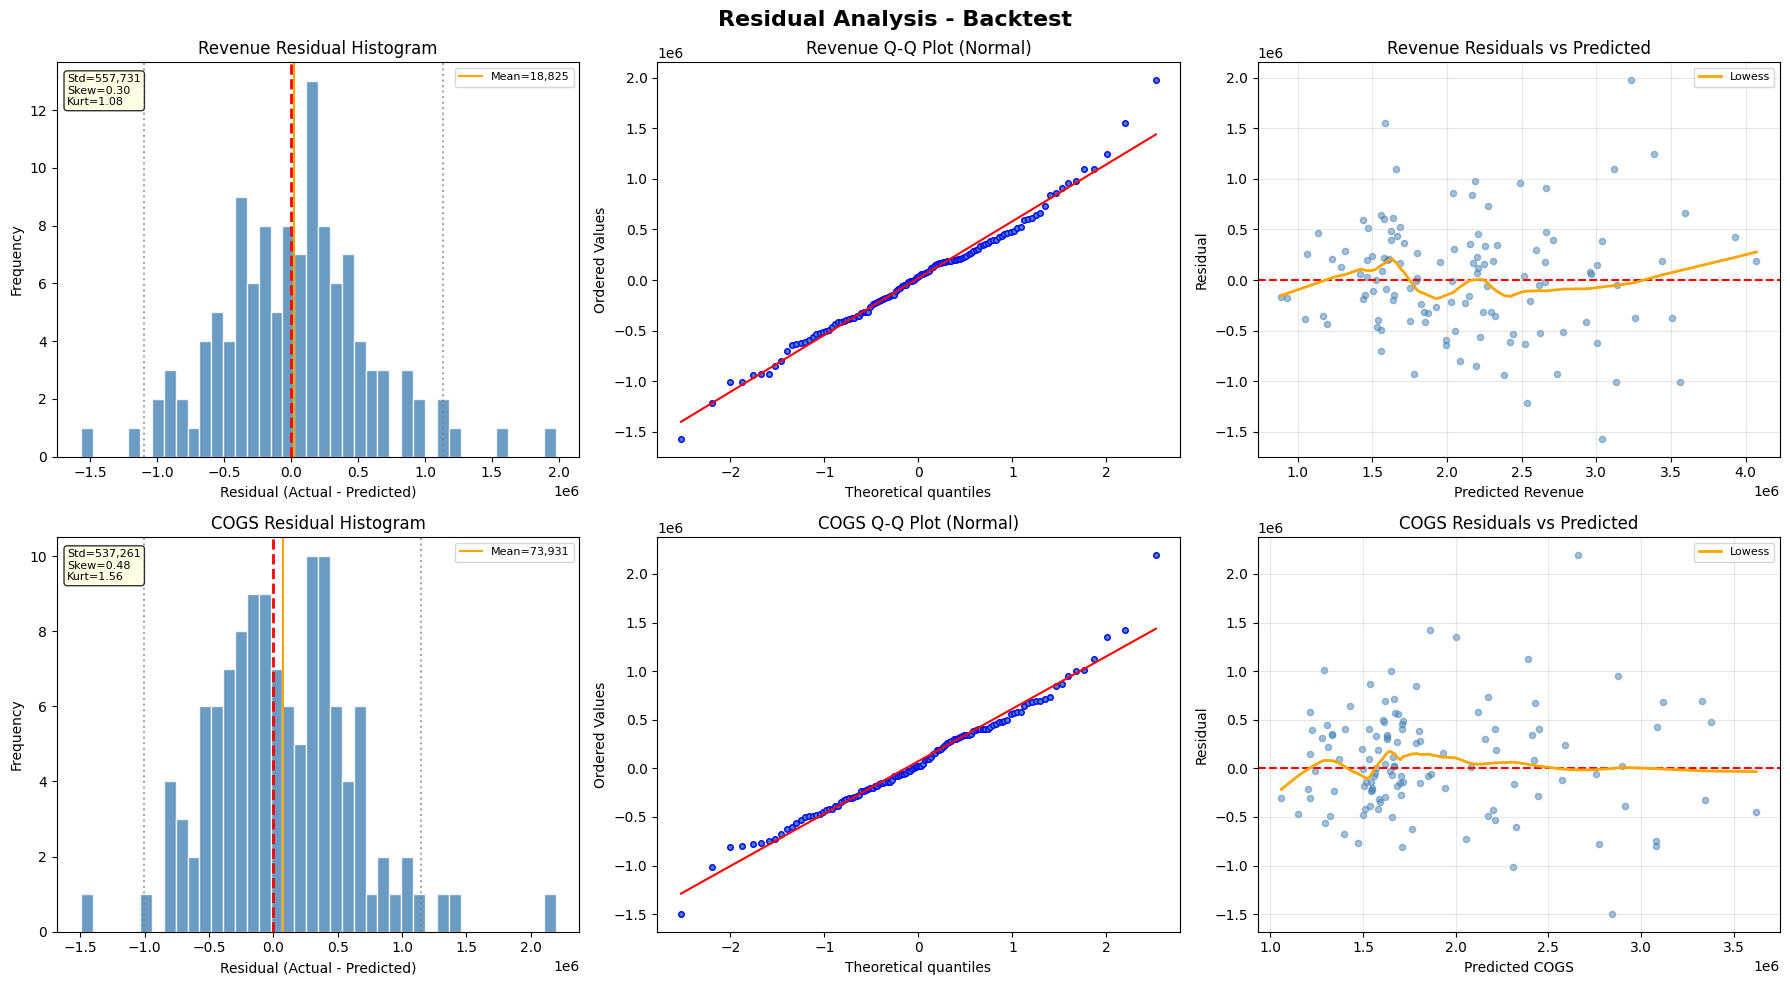

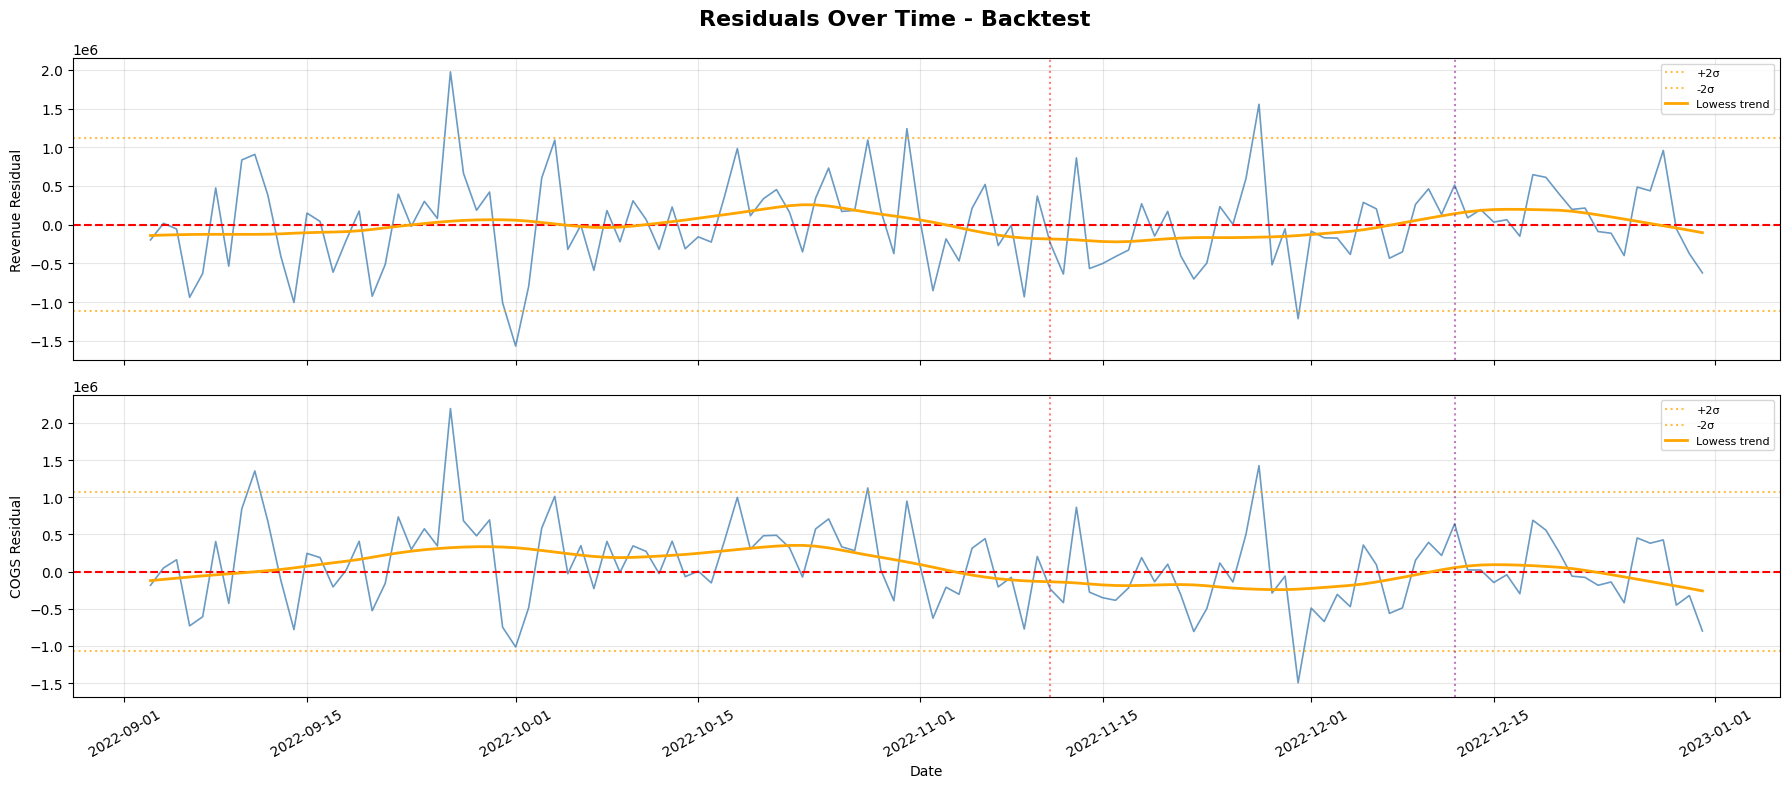


Residual Statistics:
  Revenue: Mean=18,825, Std=557,731, Skew=0.300, Kurt=1.077
  COGS:    Mean=73,931, Std=537,261, Skew=0.477, Kurt=1.560


In [5]:
# ────────────────────────────────────────────────
# Residual Analysis
# ────────────────────────────────────────────────
if not DATA_FILE.exists() or not manifest_path.exists():
    print("[WARN] Khong du du lieu. Hay chay Datathon.ipynb truoc.")
else:
    with open(manifest_path) as f:
        manifest = json.load(f)

    best_rev_family = manifest["best_final_choice"][TARGET_REVENUE]
    best_cogs_family = manifest["best_final_choice"][TARGET_COGS]

    rev_model_path = MODEL_DIR / f"best_{TARGET_REVENUE}_{best_rev_family}.joblib"
    cogs_model_path = MODEL_DIR / f"best_{TARGET_COGS}_{best_cogs_family}.joblib"
    if not rev_model_path.exists() or not cogs_model_path.exists():
        for fam in ["cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_REVENUE}_{fam}.joblib"
            if p.exists():
                rev_model_path = p
                best_rev_family = fam
                break
        for fam in ["cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_COGS}_{fam}.joblib"
            if p.exists():
                cogs_model_path = p
                best_cogs_family = fam
                break

    if not rev_model_path.exists() or not cogs_model_path.exists():
        print("[WARN] Khong tim thay model. Bo qua residual analysis.")
    else:
        rev_model = joblib.load(rev_model_path)
        cogs_model = joblib.load(cogs_model_path)
        rev_feature_cols = list(getattr(rev_model, "feature_names_in_", getattr(rev_model, "feature_names_", getattr(rev_model, "feature_name_", []))))
        cogs_feature_cols = list(getattr(cogs_model, "feature_names_in_", getattr(cogs_model, "feature_names_", getattr(cogs_model, "feature_name_", []))))

        n_folds = manifest.get("folds", 2)
        horizon = manifest.get("horizon", 60)
        min_train = manifest.get("min_train_rows", 730)

        n = len(train_df)
        splits = []
        for i in range(n_folds, 0, -1):
            vs = n - i * horizon
            ve = vs + horizon
            if vs >= min_train and ve <= n:
                splits.append((np.arange(0, vs), np.arange(vs, ve)))

        all_residuals_rev = []
        all_residuals_cogs = []
        all_dates_res = []
        all_pred_rev = []
        all_pred_cogs = []
        all_true_rev = []
        all_true_cogs = []

        for fold_id, (tr_idx, va_idx) in enumerate(splits):
            tr_df = train_df.iloc[tr_idx].copy().reset_index(drop=True)
            va_df = train_df.iloc[va_idx].copy().reset_index(drop=True)

            for target_col, model, feature_cols in [
                (TARGET_REVENUE, rev_model, rev_feature_cols),
                (TARGET_COGS, cogs_model, cogs_feature_cols),
            ]:
                fold_model = type(model)(**model.get_params())
                fold_model.fit(tr_df[feature_cols], tr_df[target_col])

                pred_df = recursive_forecast(
                    model=fold_model,
                    train_df=tr_df[[DATE_COL, target_col] + feature_cols],
                    future_dates=va_df[DATE_COL].tolist(),
                    target_col=target_col,
                    feature_cols=feature_cols,
                    known_future_df=va_df[[DATE_COL] + feature_cols],
                )
                merged = va_df[[DATE_COL, target_col]].merge(
                    pred_df, on=DATE_COL, how="left", suffixes=("_true", "_pred")
                )
                y_true = merged[f"{target_col}_true"].values
                y_pred = merged[f"{target_col}_pred"].values
                residuals = y_true - y_pred
                if target_col == TARGET_REVENUE:
                    all_residuals_rev.extend(residuals)
                    all_pred_rev.extend(y_pred)
                    all_true_rev.extend(y_true)
    
                    all_dates_res.extend(merged[DATE_COL].tolist()) 
                else:
                    all_residuals_cogs.extend(residuals)
                    all_pred_cogs.extend(y_pred)
                    all_true_cogs.extend(y_true)

        all_residuals_rev = np.array(all_residuals_rev)
        all_residuals_cogs = np.array(all_residuals_cogs)
        all_dates_res = pd.to_datetime(all_dates_res)

        # ── Figure 1: Histogram + Q-Q Plot ──
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle("Residual Analysis - Backtest", fontsize=16, fontweight="bold")

        for row, (residuals, label, family) in enumerate([
            (all_residuals_rev, "Revenue", best_rev_family),
            (all_residuals_cogs, "COGS", best_cogs_family),
        ]):
            # Histogram
            ax = axes[row, 0]
            ax.hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
            ax.axvline(0, color="red", linestyle="--", linewidth=2)
            ax.axvline(np.mean(residuals), color="orange", linestyle="-", linewidth=1.5,
                       label=f"Mean={np.mean(residuals):,.0f}")
            ax.axvline(np.mean(residuals) + 2*np.std(residuals), color="gray", linestyle=":", alpha=0.7)
            ax.axvline(np.mean(residuals) - 2*np.std(residuals), color="gray", linestyle=":", alpha=0.7)
            ax.set_xlabel("Residual (Actual - Predicted)")
            ax.set_ylabel("Frequency")
            ax.set_title(f"{label} Residual Histogram")
            ax.legend(fontsize=8)
            ax.text(0.02, 0.97,
                    f'Std={np.std(residuals):,.0f}\nSkew={pd.Series(residuals).skew():.2f}\nKurt={pd.Series(residuals).kurtosis():.2f}',
                    transform=ax.transAxes, fontsize=8, verticalalignment="top",
                    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

            # Q-Q Plot
            ax = axes[row, 1]
            from scipy import stats as sp_stats
            sp_stats.probplot(residuals, dist="norm", plot=ax)
            ax.set_title(f"{label} Q-Q Plot (Normal)")
            ax.get_lines()[0].set_markerfacecolor("steelblue")
            ax.get_lines()[0].set_markersize(4)
            ax.get_lines()[1].set_color("red")

            # Residual vs Predicted
            ax = axes[row, 2]
            pred_arr = all_pred_rev if label == "Revenue" else all_pred_cogs
            ax.scatter(pred_arr, residuals, alpha=0.5, s=20, color="steelblue")
            ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
            # Lowess smooth
            try:
                from statsmodels.nonparametric.smoothers_lowess import lowess
                smooth = lowess(residuals, np.array(pred_arr), frac=0.3)
                ax.plot(smooth[:, 0], smooth[:, 1], color="orange", linewidth=2, label="Lowess")
            except Exception:
                pass
            ax.set_xlabel(f"Predicted {label}")
            ax.set_ylabel("Residual")
            ax.set_title(f"{label} Residuals vs Predicted")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        # Hide unused axes
        for ax in axes[1, :]:
            pass

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "residual_analysis_hist_qq.png", dpi=300, bbox_inches="tight")
        plt.show()

        # ── Figure 2: Residuals over Time ──
        fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
        fig.suptitle("Residuals Over Time - Backtest", fontsize=16, fontweight="bold")

        for ax, residuals, true_vals, label in [
            (axes[0], all_residuals_rev, all_true_rev, "Revenue"),
            (axes[1], all_residuals_cogs, all_true_cogs, "COGS"),
        ]:
            res_series = pd.Series(residuals, index=all_dates_res)
            ax.plot(all_dates_res, residuals, color="steelblue", alpha=0.8, linewidth=1.2)
            ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
            ax.axhline(2*np.std(residuals), color="orange", linestyle=":", alpha=0.7, label=f"+2σ")
            ax.axhline(-2*np.std(residuals), color="orange", linestyle=":", alpha=0.7, label=f"-2σ")
            # Lowess smooth
            try:
                smooth = lowess(residuals, np.arange(len(residuals)), frac=0.2)
                ax.plot(all_dates_res, smooth[:, 1], color="orange", linewidth=2, label="Lowess trend")
            except Exception:
                pass
            ax.set_ylabel(f"{label} Residual")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

            # Danh dau mega sale
            mega_dates = [d for d in all_dates_res if d.month == 11 and d.day == 11]
            for md in mega_dates:
                ax.axvline(md, color="red", linestyle=":", alpha=0.5)
            mega_dates_12 = [d for d in all_dates_res if d.month == 12 and d.day == 12]
            for md in mega_dates_12:
                ax.axvline(md, color="purple", linestyle=":", alpha=0.5)

        axes[1].set_xlabel("Date")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "residual_analysis_time.png", dpi=300, bbox_inches="tight")
        plt.show()

        print(f"\nResidual Statistics:")
        print(f"  Revenue: Mean={np.mean(all_residuals_rev):,.0f}, Std={np.std(all_residuals_rev):,.0f}, "
              f"Skew={pd.Series(all_residuals_rev).skew():.3f}, Kurt={pd.Series(all_residuals_rev).kurtosis():.3f}")
        print(f"  COGS:    Mean={np.mean(all_residuals_cogs):,.0f}, Std={np.std(all_residuals_cogs):,.0f}, "
              f"Skew={pd.Series(all_residuals_cogs).skew():.3f}, Kurt={pd.Series(all_residuals_cogs).kurtosis():.3f}")
        

## 6. SHAP Analysis {#6}



SHAP Analysis
  Revenue model: best_revenue_cat.joblib
  COGS model:    best_cogs_xgb.joblib
  So features: Revenue=82, COGS=82

Dang tinh SHAP values (vui long doi...)...
  - Revenue SHAP...
  - COGS SHAP...


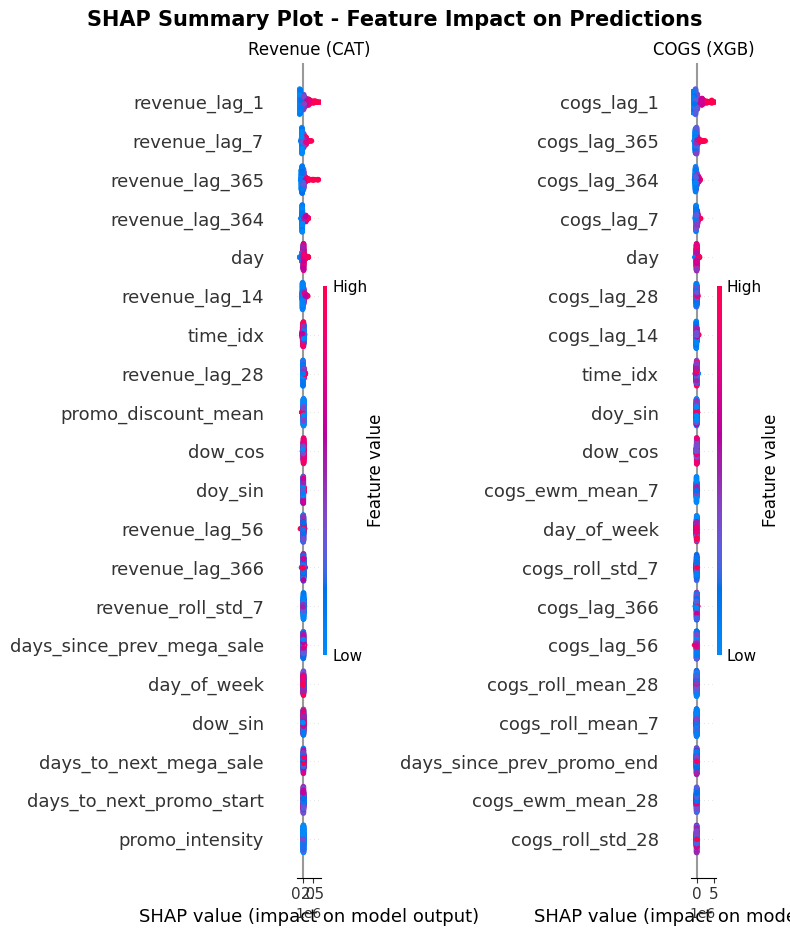

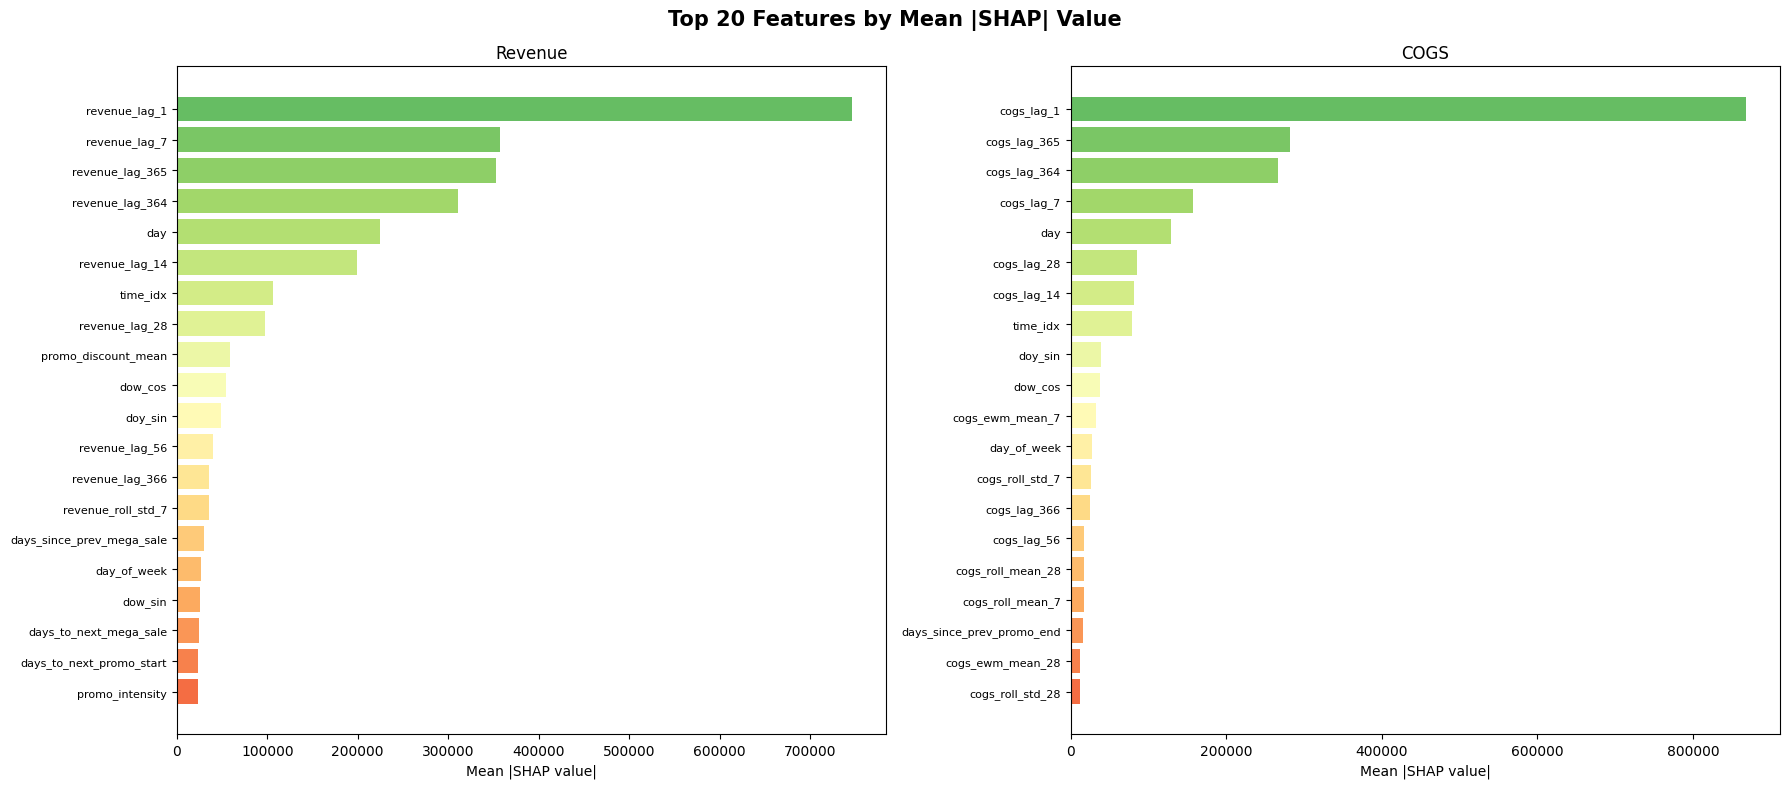

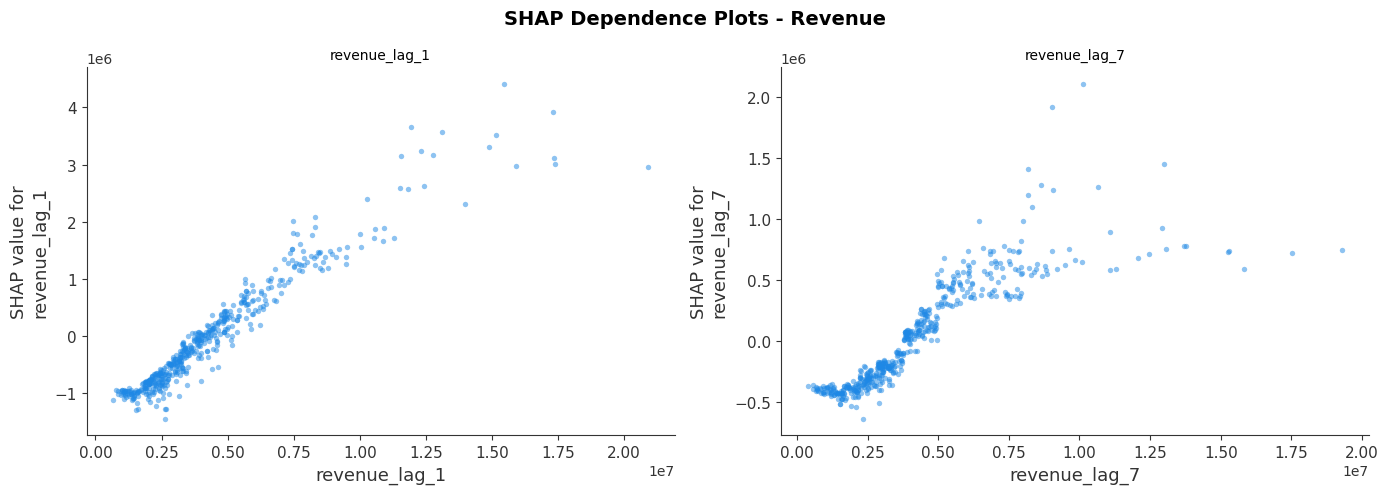

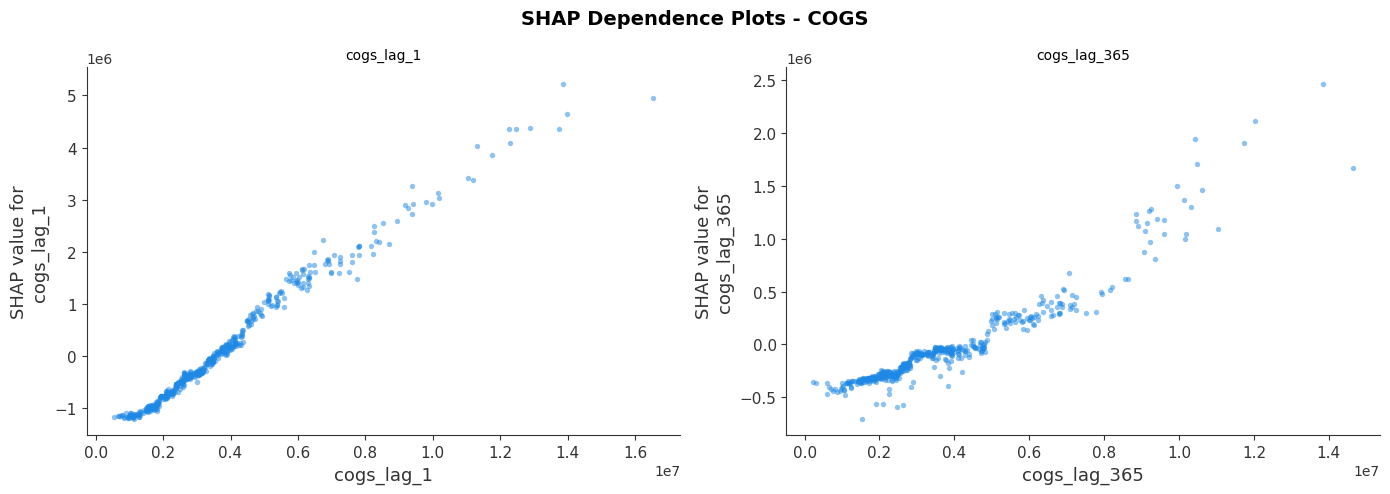


Top 10 Features by Mean |SHAP| - REVENUE
 rank             feature  mean_abs_shap      shap_std
    1       revenue_lag_1  746950.832296 633171.188276
    2       revenue_lag_7  357021.139138 241586.875939
    3     revenue_lag_365  352988.687103 462381.063662
    4     revenue_lag_364  310890.340357 247459.443125
    5                 day  224751.636298 263239.855280
    6      revenue_lag_14  198639.567998 139308.048644
    7            time_idx  105841.127895  75191.608169
    8      revenue_lag_28   96989.278780  76331.380907
    9 promo_discount_mean   58343.793528  54444.042993
   10             dow_cos   54001.813898  38413.429751

Top 10 Features by Mean |SHAP| - COGS
 rank      feature  mean_abs_shap      shap_std
    1   cogs_lag_1  868649.500000 801132.937500
    2 cogs_lag_365  281797.968750 295481.187500
    3 cogs_lag_364  266207.656250 181194.640625
    4   cogs_lag_7  156828.906250 107541.804688
    5          day  129701.226562 143413.640625
    6  cogs_lag_28   85355

In [6]:
# ────────────────────────────────────────────────
# SHAP Analysis - Revenue va COGS
# ────────────────────────────────────────────────
if not DATA_FILE.exists() or not manifest_path.exists():
    print("[WARN] Khong du du lieu. Hay chay Datathon.ipynb truoc.")
else:
    with open(manifest_path) as f:
        manifest = json.load(f)

    best_rev_family = manifest["best_final_choice"][TARGET_REVENUE]
    best_cogs_family = manifest["best_final_choice"][TARGET_COGS]

    rev_model_path = MODEL_DIR / f"best_{TARGET_REVENUE}_{best_rev_family}.joblib"
    cogs_model_path = MODEL_DIR / f"best_{TARGET_COGS}_{best_cogs_family}.joblib"
    
    # Fallback
    if not rev_model_path.exists():
        for fam in ["cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_REVENUE}_{fam}.joblib"
            if p.exists():
                rev_model_path = p
                best_rev_family = fam
                break
    if not cogs_model_path.exists():
        for fam in ["cat", "lgbm", "xgb"]:
            p = MODEL_DIR / f"best_{TARGET_COGS}_{fam}.joblib"
            if p.exists():
                cogs_model_path = p
                best_cogs_family = fam
                break

    if not rev_model_path.exists() or not cogs_model_path.exists():
        print("[WARN] Khong tim thay model files. Khong chay duoc SHAP.")
        print("  Thu tai: outputs/models_deep_tune/best_revenue_*.joblib va best_cogs_*.joblib")
    else:
        rev_model = joblib.load(rev_model_path)
        cogs_model = joblib.load(cogs_model_path)
        rev_feature_cols = getattr(rev_model, "feature_names_in_", getattr(rev_model, "feature_names_", getattr(rev_model, "feature_name_", None)))
        cogs_feature_cols = getattr(cogs_model, "feature_names_in_", getattr(cogs_model, "feature_names_", getattr(cogs_model, "feature_name_", None)))

        print(f"SHAP Analysis")
        print(f"  Revenue model: {rev_model_path.name}")
        print(f"  COGS model:    {cogs_model_path.name}")
        print(f"  So features: Revenue={len(rev_feature_cols)}, COGS={len(cogs_feature_cols)}")

        X_rev = train_df[rev_feature_cols].dropna().sample(n=min(500, len(train_df)), random_state=42)
        X_cogs = train_df[cogs_feature_cols].dropna().sample(n=min(500, len(train_df)), random_state=42)

        # SHAP Explainer
        print("\nDang tinh SHAP values (vui long doi...)...")
        
        # Revenue
        print("  - Revenue SHAP...")
        rev_explainer = shap.TreeExplainer(rev_model)
        rev_shap_values = rev_explainer.shap_values(X_rev)
        
        # COGS
        print("  - COGS SHAP...")
        cogs_explainer = shap.TreeExplainer(cogs_model)
        cogs_shap_values = cogs_explainer.shap_values(X_cogs)

        # ── Summary Plot ──
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        fig.suptitle("SHAP Summary Plot - Feature Impact on Predictions", fontsize=15, fontweight="bold")

        plt.subplot(1, 2, 1)
        shap.summary_plot(rev_shap_values, X_rev, show=False, max_display=20)
        plt.title(f"Revenue ({best_rev_family.upper()})", fontsize=12)
        plt.xlabel("SHAP value (impact on model output)")

        plt.subplot(1, 2, 2)
        shap.summary_plot(cogs_shap_values, X_cogs, show=False, max_display=20)
        plt.title(f"COGS ({best_cogs_family.upper()})", fontsize=12)
        plt.xlabel("SHAP value (impact on model output)")

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "shap_summary_combined.png", dpi=300, bbox_inches="tight")
        plt.show()


        # ── Top Features SHAP Bar ──
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        fig.suptitle("Top 20 Features by Mean |SHAP| Value", fontsize=15, fontweight="bold")

        for ax, shap_vals, X, name in [
            (axes[0], rev_shap_values, X_rev, "Revenue"),
            (axes[1], cogs_shap_values, X_cogs, "COGS"),
        ]:
            mean_abs_shap = np.abs(shap_vals).mean(axis=0)
            shap_df = pd.DataFrame({"feature": X.columns, "mean_abs_shap": mean_abs_shap})
            shap_df = shap_df.sort_values("mean_abs_shap", ascending=False).head(20)
            
            colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(shap_df)))
            ax.barh(shap_df["feature"], shap_df["mean_abs_shap"], color=colors)
            ax.set_xlabel("Mean |SHAP value|")
            ax.set_title(f"{name}", fontsize=12)
            ax.tick_params(axis="y", labelsize=8)
            ax.invert_yaxis()

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "shap_bar_combined.png", dpi=300, bbox_inches="tight")
        plt.show()
    

        # ── Dependence Plots cho top 2 features moi target ──
        top_n = 2
        for shap_vals, X, name in [
            (rev_shap_values, X_rev, "Revenue"),
            (cogs_shap_values, X_cogs, "COGS"),
        ]:
            mean_abs_shap = np.abs(shap_vals).mean(axis=0)
            top_features = X.columns[np.argsort(mean_abs_shap)[::-1][:top_n]].tolist()

            fig, axes = plt.subplots(1, top_n, figsize=(14, 5))
            fig.suptitle(f"SHAP Dependence Plots - {name}", fontsize=14, fontweight="bold")
            if top_n == 1:
                axes = [axes]

            for i, feat in enumerate(top_features):
                shap.dependence_plot(feat, shap_vals, X, show=False,
                                     interaction_index=None, alpha=0.5, dot_size=15, ax=axes[i])
                

                axes[i].set_title(f"{feat}", fontsize=10)

            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f"shap_dependence_{name.lower()}.png", dpi=300, bbox_inches="tight")
            plt.show()
            

        # ── Print Top 10 SHAP values table ──
        print(f"\n{'='*60}")
        print(f"Top 10 Features by Mean |SHAP| - REVENUE")
        print(f"{'='*60}")
        rev_shap_df = pd.DataFrame({
            "feature": X_rev.columns,
            "mean_abs_shap": np.abs(rev_shap_values).mean(axis=0),
            "shap_std": np.abs(rev_shap_values).std(axis=0),
        }).sort_values("mean_abs_shap", ascending=False).head(10)
        rev_shap_df["rank"] = range(1, len(rev_shap_df)+1)
        print(rev_shap_df[["rank","feature","mean_abs_shap","shap_std"]].to_string(index=False))

        print(f"\n{'='*60}")
        print(f"Top 10 Features by Mean |SHAP| - COGS")
        print(f"{'='*60}")
        cogs_shap_df = pd.DataFrame({
            "feature": X_cogs.columns,
            "mean_abs_shap": np.abs(cogs_shap_values).mean(axis=0),
            "shap_std": np.abs(cogs_shap_values).std(axis=0),
        }).sort_values("mean_abs_shap", ascending=False).head(10)
        cogs_shap_df["rank"] = range(1, len(cogs_shap_df)+1)
        print(cogs_shap_df[["rank","feature","mean_abs_shap","shap_std"]].to_string(index=False))

## 7. Tổng kết {#7}

In [7]:
# ────────────────────────────────────────────────
# Tong ket
# ────────────────────────────────────────────────
print("=" * 70)
print("TONG KET BAO CAO - DATATHON 2026 ROUND 1")
print("=" * 70)

if manifest_path.exists():
    with open(manifest_path) as f:
        manifest = json.load(f)

    print(f"\n[PIPELINE CONFIG]")
    print(f"  Data file:    {manifest['data_file']}")
    print(f"  Revenue features: {manifest['revenue_features']}")
    print(f"  COGS features:    {manifest['cogs_features']}")
    print(f"  Known-future features: {manifest['known_future_features']}")
    print(f"  Backtest: {manifest['folds']} folds, horizon={manifest['horizon']} ngay")
    print(f"  Search: LGBM={manifest['search_iters']['lgbm']}, XGB={manifest['search_iters']['xgb']}, CAT={manifest['search_iters']['cat']} trials")
    print(f"  Runtime: {manifest['runtime_choices']}")

    print(f"\n[MODEL CHOT]")
    print(f"  Revenue: {manifest['best_final_choice']['revenue']}")
    print(f"  COGS:    {manifest['best_final_choice']['cogs']}")

if df_rev is not None and df_cogs is not None:
    best_rev = df_rev.iloc[0]
    best_cogs = df_cogs.iloc[0]

    print(f"\n[BACKTEST METRICS - BEST MODEL]")
    print(f"  REVENUE ({best_rev['model_family']}):")
    print(f"    RMSE:  {best_rev['mean_rmse']:>12,.0f}  (±{best_rev['std_rmse']:,.0f})")
    print(f"    MAE:   {best_rev['mean_mae']:>12,.0f}  (±{best_rev['std_mae']:,.0f})")
    print(f"    R²:    {best_rev['mean_r2']:>12.4f}  (±{best_rev['std_r2']:.4f})")
    if 'mean_mape' in best_rev and pd.notna(best_rev.get('mean_mape')):
        print(f"    MAPE:  {best_rev['mean_mape']:>12.2f}%  (±{best_rev['std_mape']:.2f}%)")
    if 'mean_wmape' in best_rev and pd.notna(best_rev.get('mean_wmape')):
        print(f"    WMAPE: {best_rev['mean_wmape']:>12.2f}%  (±{best_rev['std_wmape']:.2f}%)")

    print(f"  COGS ({best_cogs['model_family']}):")
    print(f"    RMSE:  {best_cogs['mean_rmse']:>12,.0f}  (±{best_cogs['std_rmse']:,.0f})")
    print(f"    MAE:   {best_cogs['mean_mae']:>12,.0f}  (±{best_cogs['std_mae']:,.0f})")
    print(f"    R²:    {best_cogs['mean_r2']:>12.4f}  (±{best_cogs['std_r2']:.4f})")
    if 'mean_mape' in best_cogs and pd.notna(best_cogs.get('mean_mape')):
        print(f"    MAPE:  {best_cogs['mean_mape']:>12.2f}%  (±{best_cogs['std_mape']:.2f}%)")
    if 'mean_wmape' in best_cogs and pd.notna(best_cogs.get('mean_wmape')):
        print(f"    WMAPE: {best_cogs['mean_wmape']:>12.2f}%  (±{best_cogs['std_wmape']:.2f}%)")

print(f"\n[ARTIFACTS DA TAO]")
for fname in [
    "submission.csv",
    "revenue_family_compare_plus_ensemble.csv",
    "cogs_family_compare_plus_ensemble.csv",
    "deep_tune_run_manifest.json",
    "feature_importance_combined.png",
    "forecast_vs_actual_backtest.png",
    "residual_analysis_hist_qq.png",
    "residual_analysis_time.png",
    "shap_summary_combined.png",
    "shap_bar_combined.png",
]:
    p = OUTPUT_DIR / fname
    status = "OK" if p.exists() else "Chua tao"
    print(f"  [{status}] {fname}")

print(f"\n{'='*70}")
print("BAO CAO HOAN TAT!")
print("=" * 70)

TONG KET BAO CAO - DATATHON 2026 ROUND 1

[PIPELINE CONFIG]
  Data file:    D:\CODEPY\Fashion_Ecom_Sales_Forecasting\outputs\daily_features_tuned_best.csv
  Revenue features: 82
  COGS features:    82
  Known-future features: 35
  Backtest: 2 folds, horizon=60 ngay
  Search: LGBM=12, XGB=12, CAT=12 trials
  Runtime: {'lgbm': 'gpu', 'xgb': 'gpu', 'cat': 'gpu'}

[MODEL CHOT]
  Revenue: ensemble_mean
  COGS:    xgb

[BACKTEST METRICS - BEST MODEL]
  REVENUE (ensemble_mean):
    RMSE:       562,155  (±44,827)
    MAE:        444,553  (±11,170)
    R²:          0.3727  (±0.1082)
  COGS (xgb):
    RMSE:       542,387  (±46,562)
    MAE:        421,197  (±18,103)
    R²:          0.3974  (±0.0202)

[ARTIFACTS DA TAO]
  [OK] submission.csv
  [OK] revenue_family_compare_plus_ensemble.csv
  [OK] cogs_family_compare_plus_ensemble.csv
  [OK] deep_tune_run_manifest.json
  [OK] feature_importance_combined.png
  [OK] forecast_vs_actual_backtest.png
  [OK] residual_analysis_hist_qq.png
  [OK] residual